# **Práctica 2: Propiedades estadísticas del lenguaje y Diversidad**

### **Nombre:** Omar Fernando Gramer Muñoz
### **Materia:** Lingüística Computacional
### **Matrícula:** 419003698

In [3]:
!pip install elotl datasets matplotlib scipy numpy pandas --quiet

In [81]:
# Importaciones
import random
import re
import string
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy.optimize import minimize

import plotly.express as px
import plotly.graph_objects as go

### Durante esta práctica estaré haciendo uso de un concepto que no vimos en clase llamado:

### **Hápax legómena**

Un **hápax legómena** (del griego: *"dicho solo una vez"*) es una palabra que
aparece **exactamente una vez** en un corpus dado.

Son relevantes para los análisis estadísticos porque funcionan como un indicador de qué tan
**natural** es la distribución de frecuencias de un corpus. En cualquier lengua
natural, los hápax representan entre el **40% y 60%** del vocabulario total: son
palabras muy específicas, tecnicismos o términos poco comunes que rara vez se
repiten.

Bajo la Ley de Zipf, los hápax corresponden al extremo derecho de la distribución, el grupo de palabras con el rango más alto y la frecuencia más baja (f = 1). Un corpus con muy pocos hápax indica que el vocabulario es **repetitivo y cerrado** ( posiblemente más aislante ), mientras que un porcentaje alto sugiere un vocabulario **rico y diverso** ( posiblemente más aglutinante ).

## **1. Verificación empírica de la Ley de Zipf**
___

#### **Verificar si la ley de Zipf se cumple en los siguientes casos en un lenguaje artificial creado por ustedes. :**

### **Creen un script que genere un texto aleatorio seleccionando caracteres al azar de un alfabeto definido.**
#### **Nota: *Asegúrense de incluir el carácter de "espacio" en su alfabeto para que el texto se divida en "palabras" de longitudes variables.***

#### **Primero creamos el lenguaje artificial**
Para hacer el experimento un poco más interesante definí un lenguaje artificial que tuviese algunos trigramas, digramas, prefijos y sufijos en lugar de solo generar carácteres y espacios al azar. Todo esto usando reglas de transición probabilisticas.

In [3]:

random.seed(42)

ROOTS = [
    # Morfemas generales
    "kal", "mis", "tor", "ven", "dral", "set", "phor", "nel",
    # Morfemas animalísticos
    "miau", "guau", "shu", "mi", "muu", "croc", "can", "fel",
    # Morfemas exóticos
    "mush", "kimi", "xoma", "xochil", "blade", "caos", "kec",
    # Morfemas acuáticos
    "aqua", "mar", "tide", "coral", "reef", "kelp",
    # Morfemas tech
    "ram", "sync", "byte", "flux", "grid", "kern",
]

PREFIXES = ["","","","","","","u","i","a","a", "rem", "al", "al", "li", "mu", "ena", "iro", "ur", "sudo", "bey"]
SUFFIXES = ["","","","","","","or", "or", "is", "is", "ado", "mi", "aro", "ix", "eon", "kul","tin"]


# Acredito MUCHO a Claude por ayudarme a generar las transiciones a continuación
# Entenderán que no hay forma de que hiciera esto a mano sin volverme loco

# ── DIGRAMAS ──────────────────────────────────────────────────────────────────
BIGRAM_TRANSITIONS = {
    # Cluster general — ciclo sólido con puentes a otros clusters
    "kal":   {"tor": 0.5, "ven": 0.3, "mis": 0.2},
    "mis":   {"kal": 0.6, "nel": 0.3, "dral": 0.1},
    "tor":   {"ven": 0.5, "set": 0.3, "phor": 0.2},
    "ven":   {"kal": 0.5, "nel": 0.3, "dral": 0.2},
    "dral":  {"mis": 0.6, "kal": 0.3, "set": 0.1},
    "set":   {"phor": 0.6, "tor": 0.3, "kal": 0.1},
    "phor":  {"nel": 0.5, "set": 0.3, "ven": 0.2},
    "nel":   {"kal": 0.5, "mis": 0.3, "phor": 0.2},
    # Cluster animalístico — se llaman mucho entre sí
    "miau":  {"shu": 0.5, "mi": 0.3, "fel": 0.2},
    "guau":  {"can": 0.6, "croc": 0.3, "muu": 0.1},
    "shu":   {"miau": 0.5, "mi": 0.3, "muu": 0.2},
    "mi":    {"miau": 0.6, "shu": 0.3, "fel": 0.1},
    "muu":   {"croc": 0.5, "guau": 0.3, "can": 0.2},
    "croc":  {"guau": 0.5, "muu": 0.3, "can": 0.2},
    "can":   {"guau": 0.6, "croc": 0.3, "shu": 0.1},
    "fel":   {"miau": 0.6, "mi": 0.3, "shu": 0.1},
    # Cluster exótico — xochil y xoma son los nodos centrales
    "mush":  {"kimi": 0.5, "xoma": 0.3, "caos": 0.2},
    "kimi":  {"xoma": 0.5, "xochil": 0.3, "mush": 0.2},
    "xoma":  {"xochil": 0.6, "kec": 0.3, "kimi": 0.1},
    "xochil":{"caos": 0.5, "blade": 0.3, "xoma": 0.2},
    "blade": {"caos": 0.5, "kec": 0.3, "xochil": 0.2},
    "caos":  {"kec": 0.5, "mush": 0.3, "blade": 0.2},
    "kec":   {"mush": 0.5, "xoma": 0.3, "caos": 0.2},
    # Cluster acuático — este es más lineal mar → profundidad
    "aqua":  {"mar": 0.6, "coral": 0.3, "tide": 0.1},
    "mar":   {"tide": 0.6, "aqua": 0.3, "reef": 0.1},
    "tide":  {"coral": 0.6, "mar": 0.3, "kelp": 0.1},
    "coral": {"reef": 0.6, "tide": 0.3, "aqua": 0.1},
    "reef":  {"kelp": 0.6, "coral": 0.3, "mar": 0.1},
    "kelp":  {"aqua": 0.6, "reef": 0.3, "tide": 0.1},
    # Cluster tech — ciclo de procesamiento: ram→sync→byte→flux→grid→kern
    "ram":   {"sync": 0.6, "byte": 0.3, "flux": 0.1},
    "sync":  {"byte": 0.6, "ram": 0.3, "grid": 0.1},
    "byte":  {"flux": 0.6, "sync": 0.3, "kern": 0.1},
    "flux":  {"grid": 0.6, "byte": 0.3, "ram": 0.1},
    "grid":  {"kern": 0.6, "flux": 0.3, "sync": 0.1},
    "kern":  {"ram": 0.6, "grid": 0.3, "byte": 0.1},
}

# ── TRIGRAMAS ─────────────────────────────────────────────────────────────────
TRIGRAM_TRANSITIONS = {
    # General
    ("kal", "tor"):     {"ven": 0.7, "set": 0.3},
    ("tor", "ven"):     {"kal": 0.7, "nel": 0.3},
    ("ven", "kal"):     {"mis": 0.7, "dral": 0.3},
    ("mis", "kal"):     {"tor": 0.7, "ven": 0.3},
    ("set", "phor"):    {"nel": 0.7, "kal": 0.3},
    ("phor", "nel"):    {"kal": 0.7, "mis": 0.3},
    ("dral", "mis"):    {"kal": 0.7, "nel": 0.3},
    ("nel", "kal"):     {"tor": 0.7, "mis": 0.3},
    # Animalístico
    ("miau", "shu"):    {"mi": 0.7, "fel": 0.3},
    ("shu", "mi"):      {"miau": 0.7, "shu": 0.3},
    ("mi", "miau"):     {"shu": 0.7, "fel": 0.3},
    ("fel", "miau"):    {"mi": 0.7, "shu": 0.3},
    ("guau", "can"):    {"croc": 0.7, "muu": 0.3},
    ("can", "croc"):    {"guau": 0.7, "muu": 0.3},
    ("croc", "guau"):   {"can": 0.7, "muu": 0.3},
    ("muu", "croc"):    {"guau": 0.7, "can": 0.3},
    # Exótico
    ("mush", "kimi"):   {"xoma": 0.7, "xochil": 0.3},
    ("kimi", "xoma"):   {"xochil": 0.7, "kec": 0.3},
    ("xoma", "xochil"): {"caos": 0.7, "blade": 0.3},
    ("xochil", "caos"): {"kec": 0.7, "blade": 0.3},
    ("blade", "caos"):  {"kec": 0.7, "mush": 0.3},
    ("caos", "kec"):    {"mush": 0.7, "xoma": 0.3},
    # Acuático
    ("aqua", "mar"):    {"tide": 0.7, "coral": 0.3},
    ("mar", "tide"):    {"coral": 0.7, "kelp": 0.3},
    ("tide", "coral"):  {"reef": 0.7, "aqua": 0.3},
    ("coral", "reef"):  {"kelp": 0.7, "mar": 0.3},
    ("reef", "kelp"):   {"aqua": 0.7, "tide": 0.3},
    ("kelp", "aqua"):   {"mar": 0.7, "reef": 0.3},
    # Tech
    ("ram", "sync"):    {"byte": 0.7, "grid": 0.3},
    ("sync", "byte"):   {"flux": 0.7, "kern": 0.3},
    ("byte", "flux"):   {"grid": 0.7, "ram": 0.3},
    ("flux", "grid"):   {"kern": 0.7, "sync": 0.3},
    ("grid", "kern"):   {"ram": 0.7, "byte": 0.3},
    ("kern", "ram"):    {"sync": 0.7, "flux": 0.3},
    # Puentes entre clusters
    ("nel", "miau"):    {"shu": 0.6, "fel": 0.4},        # general → animalístico
    ("fel", "kal"):     {"tor": 0.6, "mis": 0.4},        # animalístico → general
    ("can", "aqua"):    {"mar": 0.6, "tide": 0.4},       # animalístico → acuático
    ("kelp", "mush"):   {"kimi": 0.6, "xoma": 0.4},      # acuático → exótico
    ("kec", "ram"):     {"sync": 0.6, "byte": 0.4},      # exótico → tech
    ("kern", "xoma"):   {"xochil": 0.6, "caos": 0.4},    # tech → exótico
    ("grid", "aqua"):   {"mar": 0.6, "coral": 0.4},      # tech → acuático
    ("reef", "miau"):   {"shu": 0.6, "mi": 0.4},         # acuático → animalístico
    ("croc", "byte"):   {"flux": 0.6, "sync": 0.4},      # animalístico → tech
    ("flux", "xochil"): {"caos": 0.6, "blade": 0.4},     # tech → exótico
}

In [4]:
# FUNCIONES DE PARA CONSTRUIR PALABRAS, ORACIONES Y CORPUS 

def weighted_choice(options: dict) -> str:
    """Elige una opción según sus probabilidades."""
    keys = list(options.keys())
    weights = list(options.values())
    return random.choices(keys, weights=weights, k=1)[0]


def next_root(prev_prev: str | None, prev: str) -> str:
    """
    Decide la siguiente raíz usando trigramas si están disponibles,
    si no, usa digramas como fallback.
    """
    trigram_key = (prev_prev, prev) if prev_prev else None
    if trigram_key and trigram_key in TRIGRAM_TRANSITIONS:
        return weighted_choice(TRIGRAM_TRANSITIONS[trigram_key])
    elif prev in BIGRAM_TRANSITIONS:
        return weighted_choice(BIGRAM_TRANSITIONS[prev])
    else:
        return random.choice(ROOTS)


def build_word(num_roots: int = None) -> str:
    """
    Construye una palabra artificial combinando:
    prefijo + raíz(es) encadenadas por n-gramas + sufijo
    """
    if num_roots is None:
        # Palabras cortas son más frecuentes (distribución realista)
        num_roots = random.choices([1, 2], weights=[0.8, 0.2])[0]

    # Primera raíz aleatoria
    roots_chain = [random.choice(ROOTS)]

    # Raíces siguientes guiadas por n-gramas
    for i in range(1, num_roots):
        prev_prev = roots_chain[-2] if len(roots_chain) >= 2 else None
        prev = roots_chain[-1]
        roots_chain.append(next_root(prev_prev, prev))

    prefix = random.choice(PREFIXES)
    suffix = random.choice(SUFFIXES)

    return prefix + "".join(roots_chain) + suffix


def generate_sentence(min_words: int = 2, max_words: int = 8) -> str:
    """Genera una oración como secuencia de palabras artificiales."""
    length = random.randint(min_words, max_words)
    return " ".join(build_word() for _ in range(length))


def generate_artificial_corpus(num_sentences: int = 10000) -> str:
    """Genera el corpus completo como texto plano."""
    return "\n".join(generate_sentence() for _ in range(num_sentences))


In [9]:
# Función del notebook de clase — convierte Counter a DataFrame ordenado por frecuencia
def counter_to_pandas(counter: Counter) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(counter, orient="index").reset_index()
    df.columns = ["word", "count"]
    df.sort_values("count", ascending=False, inplace=True)
    df.reset_index(inplace=True, drop=True)
    return df

In [40]:
# Generamos el corpus del lenguaje artificial
print("Generando corpus artificial...")
artificial_corpus = generate_artificial_corpus(num_sentences=200_000)

# Muestreo de palabras generadas
sample_words = [build_word() for _ in range(15)]
print(f"\nEjemplos de palabras generadas: {sample_words}")
print(f"\nEjemplo de oración: '{generate_sentence()}'")
print(f"\nTamaño del corpus: {len(artificial_corpus):,} caracteres")

Generando corpus artificial...

Ejemplos de palabras generadas: ['reef', 'alguau', 'likelpeon', 'alrambyte', 'guaucan', 'nelor', 'kimikul', 'alcaosmushor', 'sudonel', 'martideado', 'enaxoma', 'uvenor', 'irotorphormi', 'kecor', 'beyvenkalix']

Ejemplo de oración: 'enamieon bytearo munel liram akern'

Tamaño del corpus: 8,510,029 caracteres


### **Obtenemos las frecuencias de las palabras generadas para este corpus artificial**

In [66]:
artificial_words = [w for w in artificial_corpus.replace("\n", " ").split(" ") if w.strip()]
artificial_vocab = Counter(artificial_words)
artificial_freqs = counter_to_pandas(artificial_vocab)

hapax = artificial_freqs[artificial_freqs["count"] == 1]

print(f"Total tokens:  {len(artificial_words):,}")
print(f"Tipos únicos:  {len(artificial_vocab):,}")
print(f"Hápax:         {len(hapax):,} ({len(hapax)/len(artificial_freqs)*100:.1f}% del vocabulario)\n")

# Renderizamos cada tabla como HTML individualmente
t1 = artificial_freqs.head(15).style \
    .set_caption("15 palabras más frecuentes") \
    .background_gradient(subset=["count"], cmap="YlOrRd") \
    .format({"count": "{:,}"}) \
    .to_html()

t2 = hapax.sample(15, random_state=42).style \
    .set_caption(f"Hápax ( {len(hapax):,} palabras | {len(hapax)/len(artificial_freqs)*100:.1f}%)") \
    .background_gradient(subset=["count"], cmap="Blues") \
    .format({"count": "{:,}"}) \
    .to_html()

# Las ponemos lado a lado con un div flex
display(HTML(f"""
<div style="display: flex; gap: 40px; align-items: flex-start;">
    <div>{t1}</div>
    <div>{t2}</div>
</div>
"""))

Total tokens:  999,382
Tipos únicos:  17,809
Hápax:         722 (4.1% del vocabulario)



,word,count
0,muu,"2,477"
1,sync,"2,459"
2,kelp,"2,458"
3,flux,"2,453"
4,kern,"2,451"
5,ram,"2,449"
6,kec,"2,449"
7,dral,"2,444"
8,reef,"2,444"
9,croc,"2,442"


Estas dos funciones las usaremos tanto para el lenguaje artificial como para el náhuatl, así que las definimos una sola vez.

In [42]:
# Función tomada del notebook de clase — convierte Counter a DataFrame ordenado por frecuencia
def counter_to_pandas(counter: Counter) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(counter, orient="index").reset_index()
    df.columns = ["word", "count"]
    df.sort_values("count", ascending=False, inplace=True)
    df.reset_index(inplace=True, drop=True)
    return df

### **Estimamos el parámetro α que mejor se ajuste a la curva**

Tal y como vimos en clase, podemos hacer una regresión lineal para minimizar la suma de los errores cuadráticos y así obtener una α que se ajuste mejor: 

$J_{MSE}=\\sum_{r}^{}(log(f(w_{r}))-(log(c)-\ \alpha log(r)))^{2}$

In [43]:
# Función para estimar alpha (parámetro de Zipf) por mínimos cuadrados
# Misma lógica que zipf_minimization_objective del notebook de clase
def estimate_zipf_alpha(freqs_df: pd.DataFrame):
    ranks = np.array(freqs_df.index) + 1  # +1 para que ranks empiecen en 1
    frequencies = np.array(freqs_df["count"])

    def objective(alpha):
        predicted = np.log(frequencies[0]) - alpha * np.log(ranks)
        return np.sum((np.log(frequencies) - predicted) ** 2)

    result = minimize(objective, 1.0)
    return result.x[0], ranks, frequencies

In [57]:
artificial_freqs = counter_to_pandas(artificial_vocab)
alpha_artificial, ranks, frequencies = estimate_zipf_alpha(artificial_freqs)
print(f"α estimado: {alpha_artificial:.4f}")

α estimado: 0.5838


### **Generación de las gráficas de rango vs. frecuencia (en escala y logarítmica)** 

In [58]:
# Función para graficar rank vs frecuencia en escala lineal y log-log
def plot_zipf(freqs_df: pd.DataFrame, title: str) -> float:
    alpha, ranks, frequencies = estimate_zipf_alpha(freqs_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    zipf_fit = frequencies[0] * (ranks ** (-alpha))

    # Escala lineal
    axes[0].plot(ranks, frequencies, '-o', markersize=2, label='Distribución real')
    axes[0].plot(ranks, zipf_fit, 'r--', label=f'Ajuste Zipf (α={alpha:.2f})')
    axes[0].set_xlabel("Rango (r)")
    axes[0].set_ylabel("Frecuencia (f)")
    axes[0].set_title(f"{title} — lineal")
    axes[0].legend()

    # Escala log-log con ajuste Zipf
    axes[1].plot(np.log(ranks), np.log(frequencies), color='b', label='Distribución real')
    axes[1].plot(
        np.log(ranks),
        np.log(frequencies[0]) - alpha * np.log(ranks),
        color='r', linestyle='--', label=f'Ajuste Zipf (α={alpha:.2f})'
    )
    axes[1].set_xlabel("log (r)")
    axes[1].set_ylabel("log (f)")
    axes[1].set_title(f"{title} — log-log")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return alpha

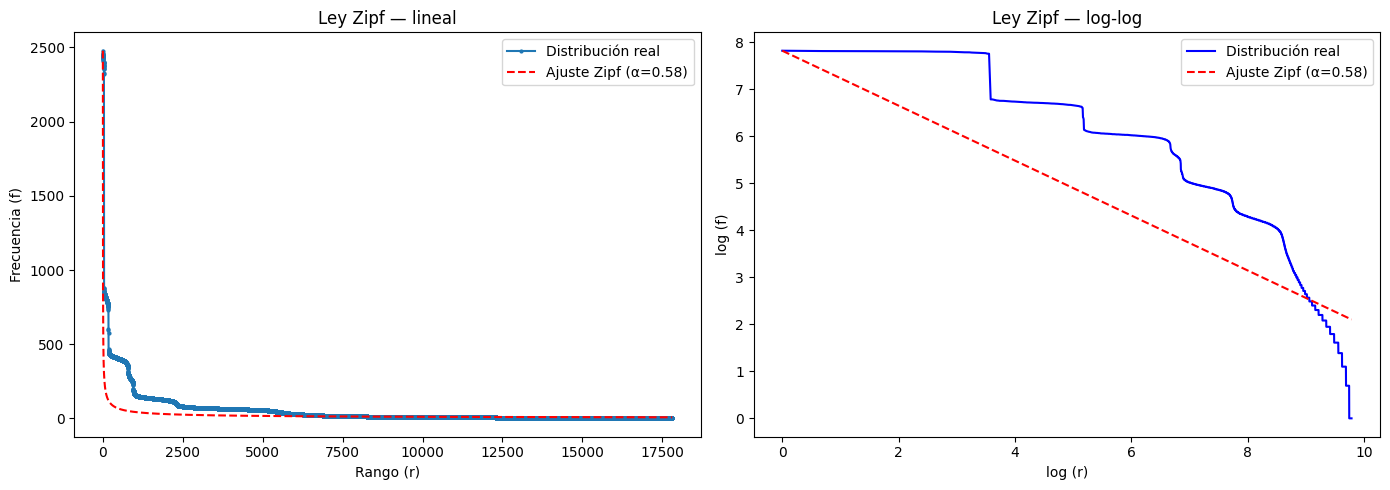

np.float64(0.5837764166504433)

In [59]:
plot_zipf(artificial_freqs, "Ley Zipf")

#### **¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.**

#### **Observaciones de la curva log**

Aunque en la gráfica lineal el lenguaje artificial aparenta seguir la Ley de Zipf,
la gráfica log-log revela que la distribución real se mantiene **por encima** del
ajuste teórico, indicando que las palabras de frecuencia alta y media son más comunes
de lo que Zipf predice. Un rasgo distintivo que podemos notar en nuestra distribución
son los **escalones** en la curva, ausentes en el corpus de Wikipedia visto en laboratorio. 
Si nos ponemos a pensar, los escalones que observamos corresponden a los niveles de complejidad
morfológica que existen en nuestro lenguaje artificial:
dentro de cada nivel todas las palabras tienen frecuencias casi idénticas generando una curva horizontal, 
y al agotarse un grupo la frecuencia cae abruptamente antes de estabilizarse en el siguiente.
Esto sugiere que **los n-gramas generan concentración de frecuencias solo dentro de cada nivel morfológico** y no de forma global.

#### **Conclusión**

A pesar del esfuerzo por generar una lengua artificial que cumpla con reglas morfológicas un poco más profundas que un lenguaje completamente aleatorio, nuestro lenguaje artificial **no cumple la Ley de Zipf** globalmente. 
Supongo que a diferencia del lenguaje natural, donde Zipf emerge de restricciones comunicativas reales (gramática,
semántica, pragmática) que producen una jerarquía continua de frecuencias, nuestro
modelo genera **grupos de palabras con frecuencias casi idénticas** porque ninguna
tiene ventaja semántica o gramatical sobre otras dentro de su mismo nivel morfológico. Sin
esa jerarquía continua que en lenguas naturales anclan las palabras funcionales
como artículos y preposiciones la distribución de nuestro lenguaje no puede formar la línea recta
característica de Zipf.

## **Análisis de Zipf para lengua natural de bajos recursos digitales**

In [47]:
import elotl.corpus
# Ver todos los corpus disponibles
for corpus in elotl.corpus.list_of_corpus():
    print(corpus)

['axolotl', 'Is a Spanish-Nahuatl parallel corpus']
['tsunkua', 'Is a Spanish-Otomí parallel corpus']
['kolo', 'Is a Spanish-Mixteco parallel corpus']


#### Eligiré el corpus en Otomí ya que me llamo Omar y de cariño me dicen Omi

In [48]:
# Tsunkua es un corpus paralelo español-otomí
corpus_otomi = elotl.corpus.load("tsunkua")

print(f"Total de entradas: {len(corpus_otomi)}")
print("\nPrimera entrada (español | otomí | fuente):")
for row in corpus_otomi[1]:
    print(row)

Total de entradas: 4963

Primera entrada (español | otomí | fuente):
Luego ya vienen, de nuevo vienen en seguimiento de Citlaltépec. A Tlacopan. Allí se establecen en el Palacio.
Ebu̱ ba ehe man'aki ba te̱nga ra t'o̱ho̱  ra thuhu ra Citlaltépec. Tlacopan, Nubia ba o̱t'ra b'u̱i ha ra ndo̱m'ihmu.
Otomí del Mezquital (ote)
Visión de los vencidos (hñahñu)
visiondelosvencidoshnahnu.pdf
5c8a6eb3656c6f188d010000


### **Obtenemos las frecuencias de las palabras generadas para el corpus Otomí**

In [67]:
# El corpus es paralelo: [español, otomí, fuente]
# Tomamos índice 1 (columna otomí) y filtramos entradas vacías
otomi_text = ' '.join([row[1] for row in corpus_otomi if row[1]])

# Normalizamos igual que en clase
otomi_text = re.sub(r'[\W]', ' ', otomi_text).lower()
otomi_words = [w for w in otomi_text.split() if w.strip()]

otomi_vocab = Counter(otomi_words)
otomi_freqs = counter_to_pandas(otomi_vocab)

print(f"Total tokens:  {len(otomi_words):,}")
print(f"Tipos únicos:  {len(otomi_vocab):,}")

hapax_otomi = otomi_freqs[otomi_freqs["count"] == 1]

t1 = otomi_freqs.head(15).style \
    .set_caption("15 palabras más frecuentes — Otomí") \
    .background_gradient(subset=["count"], cmap="YlOrRd") \
    .format({"count": "{:,}"}) \
    .to_html()

t2 = hapax_otomi.sample(15, random_state=42).style \
    .set_caption(f"Hápax ( {len(hapax_otomi):,} palabras | {len(hapax_otomi)/len(otomi_freqs)*100:.1f}%)") \
    .background_gradient(subset=["count"], cmap="Blues") \
    .format({"count": "{:,}"}) \
    .to_html()

display(HTML(f"""
<div style="display: flex; gap: 40px; align-items: flex-start;">
    <div>{t1}</div>
    <div>{t2}</div>
</div>
"""))

Total tokens:  81,034
Tipos únicos:  6,656


,word,count
0,ra,"5,798"
1,ya,"3,892"
2,a,"3,060"
3,i,"2,186"
4,bi,"2,152"
5,mi,"1,790"
6,u,"1,643"
7,t,"1,508"
8,e,"1,503"
9,o,"1,293"


### **Estimamos el parámetro α que mejor se ajuste a la curva**

In [55]:
otomi_freqs = counter_to_pandas(otomi_vocab)
alpha_otomi, ranks, frequencies = estimate_zipf_alpha(otomi_freqs)
print(f"α estimado: {alpha_otomi:.4f}")

α estimado: 1.0261


### **Generación de las gráficas de rango vs. frecuencia (en escala y logarítmica)** 

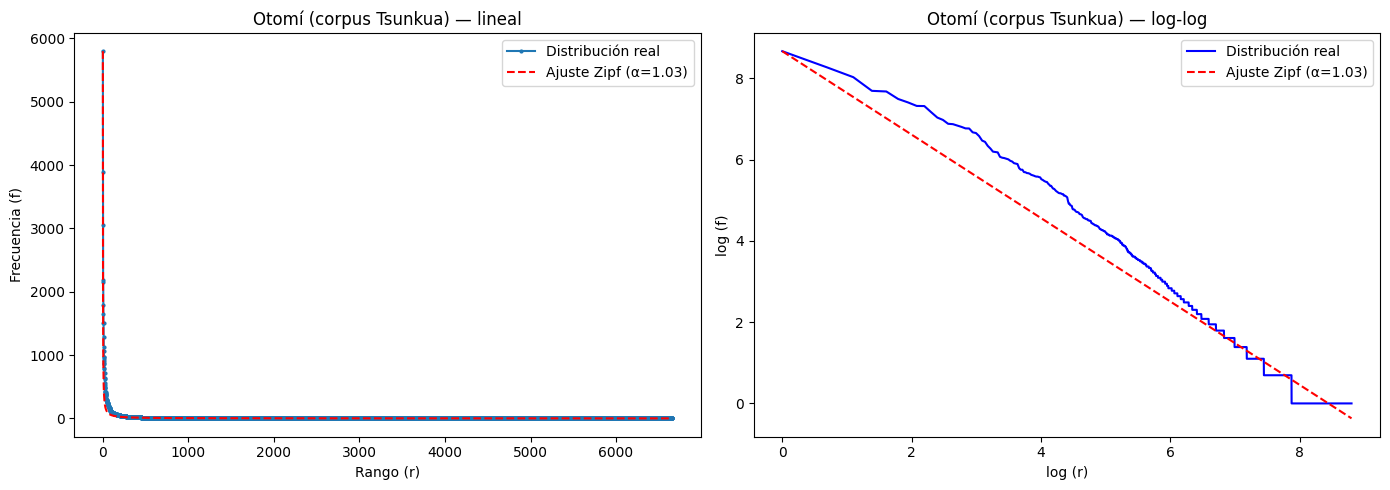

In [56]:
alpha_otomi = plot_zipf(otomi_freqs, "Otomí (corpus Tsunkua)")

#### **¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.**

#### **Observaciones de la curva log-log**

La curva log-log del otomí es **mucho más similar a una línea recta**, comportándose de forma muy
similar al corpus de Wikipedia en español visto en clase. Se aleja ligeramente por
encima del ajuste en los rangos bajos (palabras muy frecuentes) y presenta pequeños
escalones en los rangos altos (palabras raras), el mismo patrón observado en el
corpus visto en el laboratorio.

#### **Conclusión**

Con un **α = 1.026**, el otomí se aproxima notablemente a la Ley de Zipf, mucho
más que el lenguaje artificial. Este resultado es significativo
considerando que el corpus Otomí es mucho más pequeño (81,034 tokens vs. los millones de
Wikipedia), lo que sugiere que la distribución de Zipf es una propiedad intrínseca
del lenguaje natural independiente del tamaño del corpus.

El dato más revelador es el **porcentaje de hápax: 60.5%**, dentro del rango
esperado para lenguas naturales (40–60%) y muy por encima del 4.1% del lenguaje
artificial. Esto refleja una característica del otomí como lengua aglutinante: al
combinar morfemas para formar palabras largas y específicas, genera un vocabulario
muy diverso donde muchas palabras aparecen solo una vez, por eso notamos 
muchos pequeños escalones al final de su curva.

En contraste, el lenguaje artificial tiene muy pocos hápax porque sus palabras
se construyen reciclando un conjunto cerrado de morfemas con transiciones fijas,
lo que concentra las frecuencias en un vocabulario reducido y repetitivo. La
ausencia de restricciones semánticas, gramaticales y pragmáticas, las mismas que
producen la jerarquía continua de Zipf en lenguas naturales como el otomí, es
precisamente lo que le impide alcanzar una distribución natural.

## **2. Visualizando la diversidad lingüística de México**
___

### **Usando los datos de Glottolog filtralos con base en la región geográfica que corresponde a México**



In [69]:
# Descargamos los dos archivos directamente desde Glottolog
!wget -q "https://cdstar.eva.mpg.de/bitstreams/EAEA0-2198-D710-AA36-0/languages_and_dialects_geo.csv" -O languages_and_dialects_geo.csv
!wget -q "https://cdstar.eva.mpg.de/bitstreams/EAEA0-2198-D710-AA36-0/glottolog_languoid.csv.zip" -O glottolog_languoid.csv.zip
!unzip -q -o glottolog_languoid.csv.zip

print("Archivos descargados:")
!ls *.csv

Archivos descargados:
languages_and_dialects_geo.csv	languoid.csv


In [74]:
languages = pd.read_csv("languages_and_dialects_geo.csv")
languoids = pd.read_csv("languoid.csv")

print("languages_and_dialects_geo")
display(languages.head(5))

print("\nlanguoid")
display(languoids.head(5))

languages_and_dialects_geo


,glottocode,name,isocodes,level,macroarea,latitude,longitude
0,3adt1234,3Ad-Tekles,NaN,dialect,Africa,NaN,NaN
1,aala1237,Aalawa,NaN,dialect,Papunesia,NaN,NaN
2,aant1238,Aantantara,NaN,dialect,Papunesia,NaN,NaN
3,aari1239,Aari,aiw,language,Africa,5.95034,36.5721
4,aari1240,Aariya,aay,language,Eurasia,NaN,NaN



languoid


,id,family_id,parent_id,name,bookkeeping,level,latitude,longitude,iso639P3code,description,markup_description,child_family_count,child_language_count,child_dialect_count,country_ids
0,3adt1234,afro1255,nort3292,3Ad-Tekles,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
1,aala1237,aust1307,ramo1244,Aalawa,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
2,aant1238,nucl1709,nort2920,Aantantara,False,dialect,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN
3,aari1238,sout2845,ahkk1235,Aari-Gayil,False,family,NaN,NaN,aiz,NaN,NaN,0,2,0,NaN
4,aari1239,sout2845,aari1238,Aari,False,language,5.95034,36.5721,aiw,NaN,NaN,0,0,0,ET


In [77]:
# Código tomado del notebook del laboratorio
# Reconstruimos el árbol genealógico de cada lengua para extraer su familia
languoids_dict = languoids.set_index('id').to_dict('index')

def reconstruir_linaje(glottocode):
    """Sube por el árbol genealógico desde la lengua hasta la familia raíz."""
    linaje = []
    current_id = glottocode
    
    # Mientras el ID actual exista y no sea nulo (NaN)
    while pd.notna(current_id) and current_id in languoids_dict:
        nodo = languoids_dict[current_id]
        
        # Filtramos lenguas artificiales o "bookkeeping"
        if nodo.get('bookkeeping') or nodo.get('name') == 'Unclassifiable':
            return "Unclassifiable"
            
        # Insertamos el nombre al inicio de la lista para mantener el orden (Raíz -> Lengua)
        linaje.insert(0, str(nodo['name']))
        
        # Subimos al nodo padre
        current_id = nodo['parent_id']
        
    return " > ".join(linaje)

In [78]:
def filtrar_y_preparar(df, min_lat, max_lat, min_lon, max_lon):
    """Filtra por coordenadas, reconstruye linajes y extrae familia lingüística."""
    filtrado = df[
        (df["latitude"]  >= min_lat) & (df["latitude"]  <= max_lat) &
        (df["longitude"] >= min_lon) & (df["longitude"] <= max_lon)
    ].copy()

    filtrado["tree"] = filtrado["glottocode"].apply(reconstruir_linaje)
    filtrado = filtrado[~filtrado["tree"].isin(["", "Unclassifiable"])].copy()

    # La familia es el primer nodo del linaje (raíz del árbol)
    filtrado["family"] = filtrado["tree"].apply(lambda t: t.split(" > ")[0])
    return filtrado


### **Filtramos por coordenadas las lenguas en México y reconstruimos el linaje**

In [79]:
# Coordenadas geográficas de México
MIN_LAT, MAX_LAT   =  14.5,  32.7
MIN_LON, MAX_LON   = -118.4, -86.8

mexico = filtrar_y_preparar(languages, MIN_LAT, MAX_LAT, MIN_LON, MAX_LON)

print(f"Lenguas encontradas en México: {len(mexico):,}")
print(f"Familias lingüísticas: {mexico['family'].nunique():,}")
print(f"\nFamilias más representadas:")
display(mexico['family'].value_counts().head(10).to_frame())

Lenguas encontradas en México: 388
Familias lingüísticas: 33

Familias más representadas:


,count
family,
Otomanguean,212
Uto-Aztecan,53
Mayan,35
Mixe-Zoque,19
Totonacan,13
Sign Language,9
Cochimi-Yuman,7
Indo-European,5
Muskogean,4


### **Mapeo geográfico de las lenguas de México utilizando un color por familia linguistica**

In [83]:
def plot_mapa(df, titulo, zoom=4, center=None):
    """Genera mapa interactivo con un color por familia lingüística."""
    fig = px.scatter_map(
        df,
        lat="latitude",
        lon="longitude",
        color="family",
        hover_name="name",
        hover_data={"family": True, "latitude": False, "longitude": False},
        title=titulo,
        map_style="carto-positron",
        zoom=zoom,
        center=center,
        height=650,
        opacity=0.85,
        size_max=10,
    )
    fig.update_traces(marker=dict(size=9))
    fig.update_layout(
        legend_title_text="Familia lingüística",
        legend=dict(x=1.01, y=1),
        margin=dict(l=0, r=0, t=40, b=0)
    )
    fig.show()

Lenguas encontradas en México: 388
Familias lingüísticas: 33


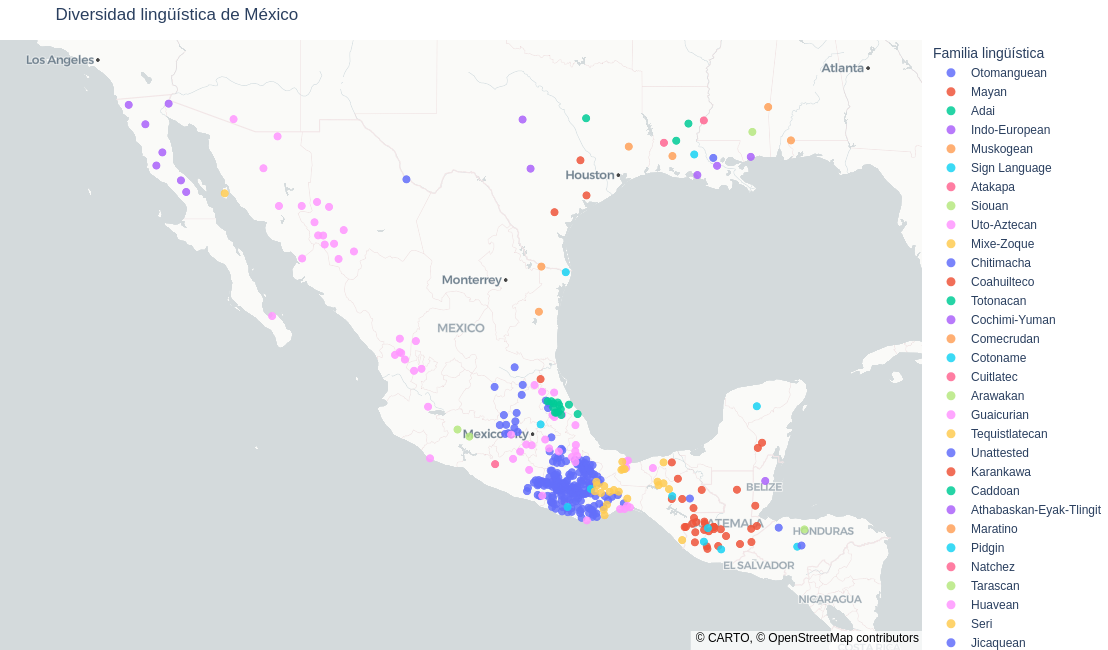

In [92]:
print(f"Lenguas encontradas en México: {len(mexico):,}")
print(f"Familias lingüísticas: {mexico['family'].nunique():,}")
plot_mapa( mexico, titulo="Diversidad lingüística de México", zoom=4, center={"lat": 23.0, "lon": -102.0})

### **Mapeo geográfico de las lenguas de Nigeria utilizando un color por familia linguistica**

Lenguas encontradas en Nigeria: 774
Familias lingüísticas: 12


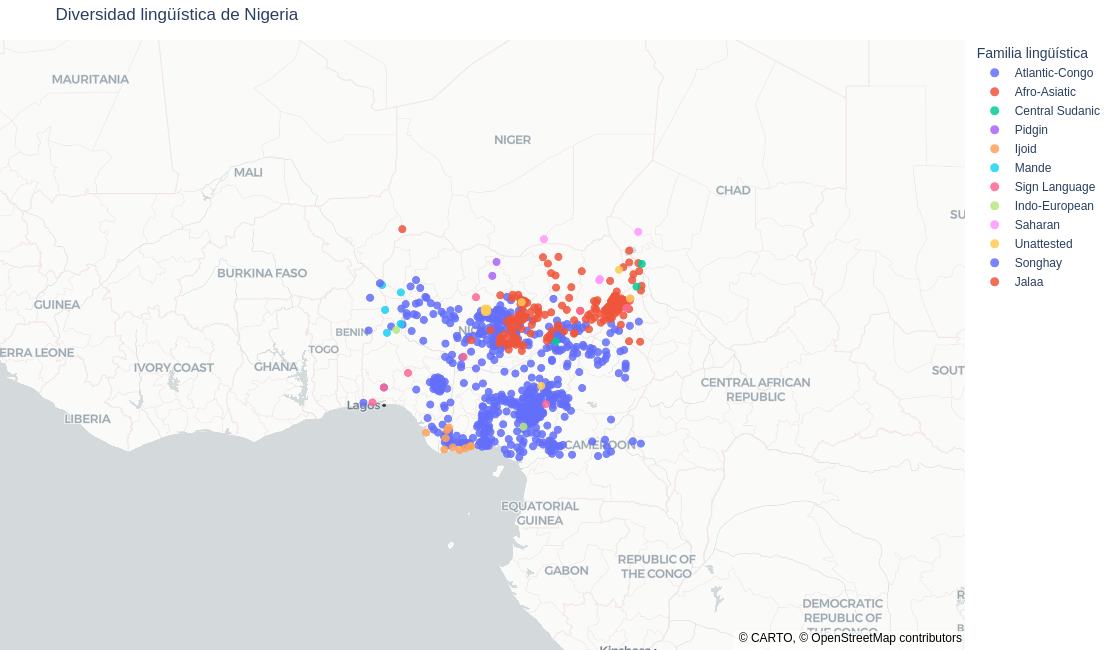

In [93]:
# Nigeria 🇳🇬 — uno de los países más diversos del mundo (~500 lenguas)
MIN_LAT_2, MAX_LAT_2 =  4.0,  14.0
MIN_LON_2, MAX_LON_2 =  2.7,  15.0
PAIS = "Nigeria"
CENTER_2 = {"lat": 9.0, "lon": 8.0}
ZOOM_2 = 4

pais2 = filtrar_y_preparar(languages, MIN_LAT_2, MAX_LAT_2, MIN_LON_2, MAX_LON_2)

print(f"Lenguas encontradas en {PAIS}: {len(pais2):,}")
print(f"Familias lingüísticas: {pais2['family'].nunique():,}")

plot_mapa(
    pais2,
    titulo=f"Diversidad lingüística de {PAIS}",
    zoom=ZOOM_2,
    center=CENTER_2
)

### **Responde las preguntas:**

#### **¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?**

México tiene **388 lenguas distribuidas en 33 familias lingüísticas**, mientras
que Nigeria tiene **774 lenguas en solo 12 familias**.

Por una parte podemos notar que Nigeria tiene el doble de lenguas que México, 
lo que refleja una enorme cantidad de hablantes y comunidades lingüísticas distintas. 
Sin embargo, la mayoría de sus lenguas pertenecen a pocas familias, principalmente Atlantic-Congo, 
lo que significa que muchas de ellas están emparentadas entre sí y que a pesar de su cantidad de lenguas, 
estas son variaciones de las pocas lenguas de las cuales descienden.

México, en cambio, presenta una diversidad genealógicamente más profunda con
33 familias lingüísticas. Muchas de sus lenguas no tienen ningún parentesco entre
sí, como el náhuatl, el maya, el mixteco o el purépecha. Esto significa que México
debe tener una historia lingüística más fragmentada y antigua, donde comunidades
aisladas desarrollaron lenguas completamente independientes a lo largo de milenios.

En ese sentido, México destaca mucho más por la diversidad genealógica de las sus lenguas y posiblemente la historia que hay detrás de estas.

#### **¿Cuál es la zona que dirias que tiene mayor diversidad en México?**

Observando el mapa, **Oaxaca** es el estado con mayor concentración de lenguas.
Sin embargo, la mayoría pertenecen a la familia **Otomangue**, lo que significa que
aunque hay muchas lenguas, gran parte de ellas están emparentadas entre sí.

Si consideramos la diversidad **genealógica** es decir, qué tan distintas son
las lenguas entre sí, la zona con mayor diversidad real sería la franja que va
desde **Oaxaca hasta Chiapas y la Península de Yucatán**, donde convergen familias
tan distintas como Otomangue, Maya y Totonacan sin ningún parentesco entre ellas.

En contraste, el norte del país muestra muy poca diversidad lingüística, con grandes
extensiones territoriales sin lenguas indígenas registradas en Glottolog, reflejo posible
del impacto histórico de la colonización y el desplazamiento de comunidades
indígenas en esa región.